# SmartSwipe — Assignment 1

**Dataset:** `transactions.csv`  
Explore the dataset on your own, find out about the different columns in the dataset.

---


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('transactions.csv')
df.head()


,txn_id,user_id,merchant,category,amount,datetime,city,cashback,status
0,TXN000001,USR0317,Nykaa,Shopping,1152.59,2024-01-01 03:29:50,Delhi,28.82,approved
1,TXN000002,USR0330,Apollo Pharmacy,Healthcare,10.00,2024-01-01 04:57:03,Hyderabad,0.27,approved
2,TXN000003,USR0096,Jio,Utilities,926.70,2024-01-01 04:57:19,Delhi,10.23,approved
3,TXN000004,USR0211,Zepto,Groceries,137.71,2024-01-01 05:33:40,Chennai,3.26,approved
4,TXN000005,USR0373,IndiGo,Travel,7001.18,2024-01-01 06:29:07,Delhi,NaN,approved


---
## Q1 — Python Fundamentals `[10 pts]`

You are given the list `amounts` below.

1. Write a function `summarise(amounts, threshold)` that returns a **dict** with keys:
   - `above_threshold`: list of values strictly greater than `threshold`, sorted descending
   - `mean`: arithmetic mean (no libraries)
   - `count_above`: integer count
2. Call it with `threshold=500` and print the result.


In [4]:
# your code here

def summarise(amounts, threshold):
  above_threshold=[]
  sum=0
  c=0
  for index in range(len(amounts)):
    if amounts[index]>threshold:
      above_threshold.append(amounts[index])
      sum=sum+amounts[index]
      c=c+1
  above_threshold.sort()
  above_threshold.reverse()
  mean=sum/c
  return {'above_threshold':above_threshold[:10],'mean':mean,'count_above':c}
print(summarise(df['amount'],500))



{'above_threshold': [np.float64(14205.88), np.float64(14011.64), np.float64(13184.18), np.float64(13086.34), np.float64(12304.94), np.float64(12250.73), np.float64(12199.01), np.float64(11818.92), np.float64(11772.79), np.float64(11662.54)], 'mean': np.float64(2465.398302675585), 'count_above': 2392}


---
## Q2 — NumPy `[15 pts]`

Load **only** the `amount` column into a NumPy array. Then:

1. Print mean, median, std, 10th and 90th percentiles.
2. Create a boolean mask for **outlier** transactions: those where `|amount − mean| > 2 × std`.
3. Normalise the array to `[0, 1]` using min-max scaling and store it as `amounts_norm`.
4. Using `np.histogram`, compute a 10-bin histogram of `amounts_norm` and print bin edges + counts (no plot needed).


In [5]:
# your code here
mean=np.mean(df['amount'])
median=np.median(df['amount'])
std=np.std(df['amount'])
percentiles=np.percentile(df['amount'],[[10,90]])
print(mean,median,std,percentiles)
print(abs(df['amount']-mean)>(2*std))


1253.0228844667695 433.385 1989.7569203389805 [[  88.25  4024.015]]
0       False
1       False
2       False
3       False
4        True
        ...  
5171    False
5172    False
5173    False
5174    False
5175    False
Name: amount, Length: 5176, dtype: bool


---
## Q3 — Pandas: Load & Explore `[15 pts]`

1. Load `smartswipe_transactions.csv` into a DataFrame `df`.
2. Print shape, dtypes, and count of missing values per column.
3. Parse `date` as `datetime` (in-place). Add a column `month` (integer, 1–12).
4. Print the statistical summary for numeric columns only.
5. How many unique `city` and `category` values exist? Print them.


In [6]:
# your code here
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df['datetime']=pd.to_datetime(df['datetime'])
df['month']=df['datetime'].dt.month
df.describe()
print(df['city'].nunique())
print(df['category'].nunique())

(5176, 9)
txn_id       object
user_id      object
merchant     object
category     object
amount      float64
datetime     object
city         object
cashback    float64
status       object
dtype: object
txn_id        0
user_id       0
merchant      0
category      0
amount        0
datetime      0
city          0
cashback    258
status        0
dtype: int64
9
9


---
## Q4 — Pandas: Filter & Transform `[20 pts]`

1. Filter to **approved** transactions only. What fraction of total transactions is this? Print as a percentage.
2. Add column `cashback_rate` = `cashback / amount`. Flag rows where this exceeds 0.10 as `suspicious` (boolean column).
3. Fill any missing `cashback` values with the **per-category median** cashback (do not use a global fill).
4. Create a `spend_tier` column: `low` (amount < 500), `mid` (500–2000), `high` (> 2000).
   Use `pd.cut` — do not write if-else chains.


In [7]:
# your code here
c=0
for index in range(len(df)):
  if(df['status'][index]=='approved'):
     c=c+1
print((c/len(df))*100)
df['cashback_rate']=df['cashback']/df['amount']
df['suspicious']=df['cashback_rate']>0.1
df['cashback']=df['cashback'].fillna(df.groupby('category')['cashback'].median())
df['spend_tier']=pd.cut(df['amount'],bins=(0,500,2000,np.inf),labels=['low','mid','high'])
df.head()

88.96831530139103


,txn_id,user_id,merchant,category,amount,datetime,city,cashback,status,month,cashback_rate,suspicious,spend_tier
0,TXN000001,USR0317,Nykaa,Shopping,1152.59,2024-01-01 03:29:50,Delhi,28.82,approved,1,0.025005,False,mid
1,TXN000002,USR0330,Apollo Pharmacy,Healthcare,10.00,2024-01-01 04:57:03,Hyderabad,0.27,approved,1,0.027000,False,low
2,TXN000003,USR0096,Jio,Utilities,926.70,2024-01-01 04:57:19,Delhi,10.23,approved,1,0.011039,False,mid
3,TXN000004,USR0211,Zepto,Groceries,137.71,2024-01-01 05:33:40,Chennai,3.26,approved,1,0.023673,False,low
4,TXN000005,USR0373,IndiGo,Travel,7001.18,2024-01-01 06:29:07,Delhi,NaN,approved,1,NaN,False,high


---
## Q5 — Pandas: Aggregation `[20 pts]`

1. For each `category`, compute: total spend, transaction count, avg transaction size, decline rate.
   Store as a clean DataFrame `category_stats` and print it sorted by total spend descending.
2. Find the **top-3 merchants** by total spend within each city. Output should be a DataFrame with columns `city`, `merchant`, `total_spend`.
3. Build a **month × category pivot table** of average transaction amounts. Print it.


In [25]:
# your code here

category_stats={
    'total spend':df.groupby('category')['amount'].sum(),
    'transaction count':df.groupby('category')['amount'].count() ,
    'avg transaction size':df.groupby('category')['amount'].mean(),
    'decline rate':df.groupby('category')['status'].apply(lambda x: (x != 'approved').mean())
}

data=pd.DataFrame(category_stats)
print(data.sort_values(by='total spend',ascending=False))
data['category'] =df['category'].unique()




               total spend  transaction count  avg transaction size  \
category                                                              
Travel          2213273.63                444           4984.850518   
Electronics     1722710.26                384           4486.224635   
Shopping        1031848.97                651           1585.021459   
Healthcare       438697.56                420           1044.518000   
Dining           371893.93                768            484.236888   
Utilities        290547.44                390            744.993436   
Groceries        195293.44                905            215.793856   
Entertainment    153913.21                527            292.055427   
Fuel              67468.01                687             98.206710   

               decline rate  
category                     
Travel             0.340090  
Electronics        0.377604  
Shopping           0.188940  
Healthcare         0.061905  
Dining             0.045573  
Utilitie

---
## Q6 — Matplotlib: Visualisation `[20 pts]`

Produce a single `fig` with **3 subplots** (layout your choice):

1. **Bar chart** — Total spend per category. Sort bars descending. Label axes.
2. **Line chart** — Daily total spend over time. Use `date` on x-axis. Rotate tick labels 45°.
3. **Histogram** — Distribution of `amount` for approved vs declined transactions overlaid (use `alpha=0.6`). Add a legend.

Titles, axis labels, and `fig.tight_layout()` are required.


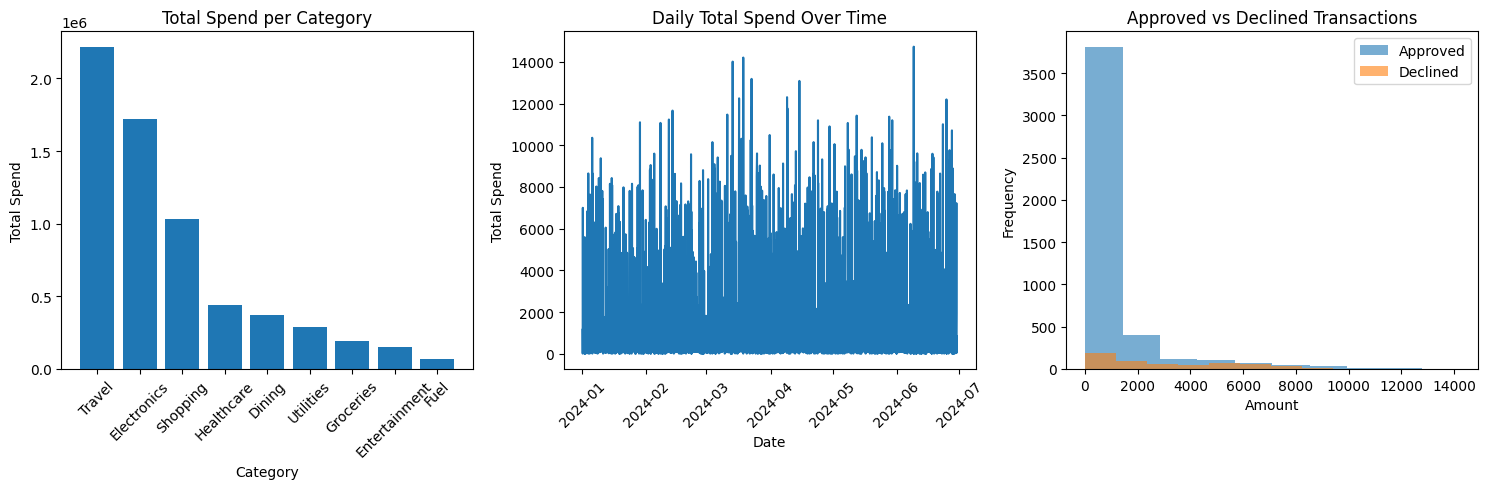

In [32]:
# your code here
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

category_spend = ( df.groupby('category')['amount'].sum().sort_values(ascending=False))

axes[0].bar(category_spend.index, category_spend.values)
axes[0].tick_params(axis='x', rotation=45)

axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Spend')
axes[0].set_title('Total Spend per Category')



daily_spend = df.groupby('datetime')['amount'].sum()

axes[1].plot(daily_spend.index, daily_spend.values)

axes[1].tick_params(axis='x', rotation=45)

axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Spend')
axes[1].set_title('Daily Total Spend Over Time')



axes[2].hist(
    df[df['status']=='approved']['amount'],
    alpha=0.6,
    label='Approved'
)

axes[2].hist(
    df[df['status']=='declined']['amount'],
    alpha=0.6,
    label='Declined'
)

axes[2].set_xlabel('Amount')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Approved vs Declined Transactions')
axes[2].legend()

fig.tight_layout()
plt.show()



---
## Q7 — Bonus `[30 pts]`

> This question is intentionally hard. Not compulsory.

**SmartSwipe Velocity Fraud Detector**

A transaction is part of a **velocity fraud event** if a single `user_id` has **≥ 3 transactions within any rolling 1-hour window**.

Date and Time are available in the CSV.

Tasks:

1. Write a function `flag_velocity_fraud(df, window='1h', min_txns=3)` that returns a boolean Series aligned to `df.index` — `True` if the transaction falls inside a fraud window for that user.
   - Must handle per-user sorted datetime correctly.
   - No row-wise Python loops over the full DataFrame.
2. Add column `velocity_fraud` using your function.
3. Compare flagged vs normal users on: avg spend, decline rate, top categories. Print a clean summary table.
4. Plot a **timeline scatter** (x = datetime, y = user_id, colour = velocity_fraud). Limit to 20 users for readability.


In [ ]:
# your code here